In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
news_clean = pd.read_csv("data/cleaned/news_clean.csv")
behaviors_clean = pd.read_csv("data/cleaned/behaviors_clean.csv")

In [4]:
behaviors_clean.head()

,user_id,history,news_id,label,hour_sin,hour_cos,day_sin,day_cos
0,U13740,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689,1,0.707107,-7.071068e-01,0.000000,1.00000
1,U13740,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N35729,0,0.707107,-7.071068e-01,0.000000,1.00000
2,U91836,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678,0,-1.000000,-1.836970e-16,0.781831,0.62349
3,U91836,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N39317,0,-1.000000,-1.836970e-16,0.781831,0.62349
4,U91836,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N58114,0,-1.000000,-1.836970e-16,0.781831,0.62349


In [6]:
import pandas as pd

# Group by user + time (important)
candidate_counts = behaviors_clean.groupby(
    ["user_id", "hour_sin", "hour_cos", "day_sin", "day_cos"]
).size()

In [7]:
candidate_lengths = candidate_counts.values

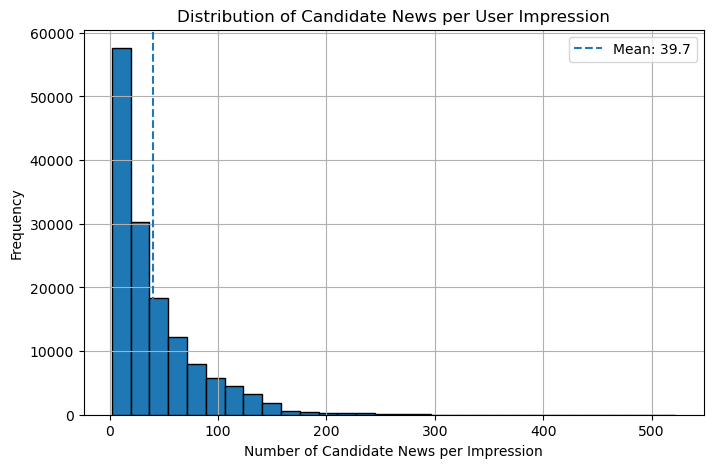

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

plt.hist(candidate_lengths, bins=30, edgecolor='black')

plt.axvline(np.mean(candidate_lengths), linestyle='--',
            label=f"Mean: {np.mean(candidate_lengths):.1f}")

plt.xlabel("Number of Candidate News per Impression")
plt.ylabel("Frequency")
plt.title("Distribution of Candidate News per User Impression")
plt.legend()
plt.grid()

plt.show()

In [10]:
print("Mean:", np.mean(candidate_lengths))
print("Median:", np.median(candidate_lengths))
print("Max:", np.max(candidate_lengths))
print("Min:", np.min(candidate_lengths))

Mean: 39.74831401365458
Median: 27.0
Max: 522
Min: 2


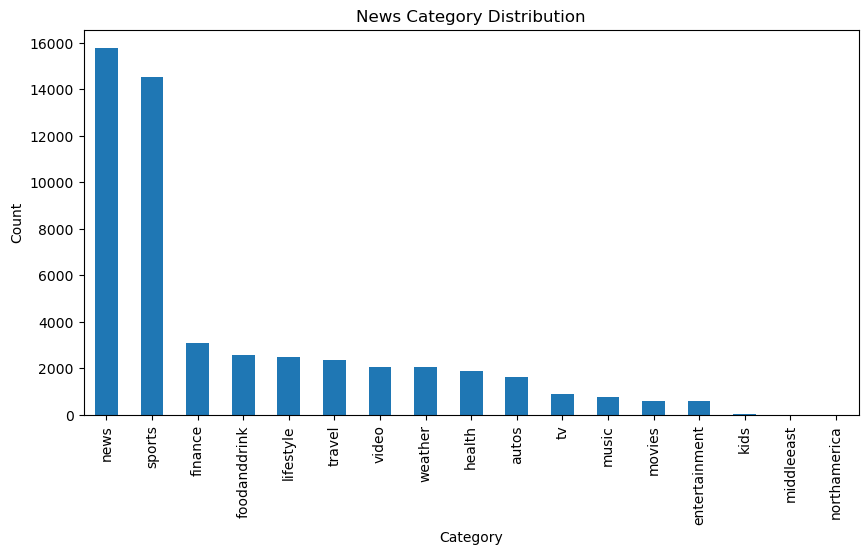

In [7]:
# Ctegory Distribution
news_clean["category"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

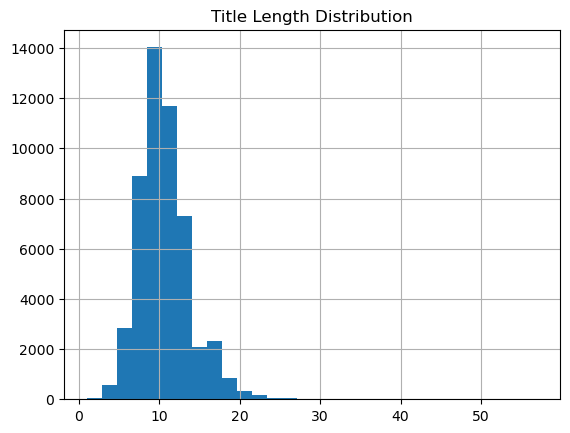

In [8]:
# Title Length
news_clean["title_len"] = news_clean["title"].apply(lambda x: len(x.split()))
news_clean["title_len"].hist(bins=30)
plt.title("Title Length Distribution")
plt.show()

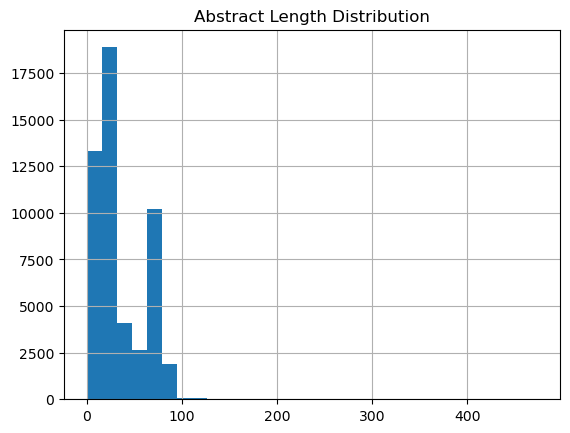

In [10]:
news_clean["abstract_len"] = news_clean["abstract"].fillna("").str.split().str.len()
news_clean["abstract_len"].hist(bins=30)
plt.title("Abstract Length Distribution")
plt.show()

## Behaviour

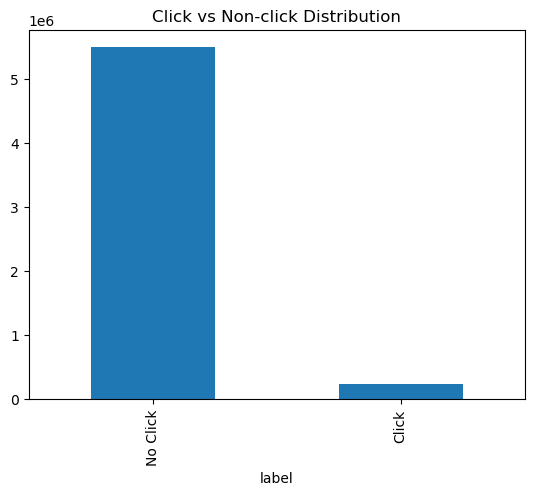

In [12]:
behaviors_clean["label"].value_counts().plot(kind="bar")
plt.title("Click vs Non-click Distribution")
plt.xticks([0,1], ["No Click", "Click"])
plt.show()

In [13]:
ctr = behaviors_clean["label"].mean()
print("CTR:", ctr)

CTR: 0.040456040378808185


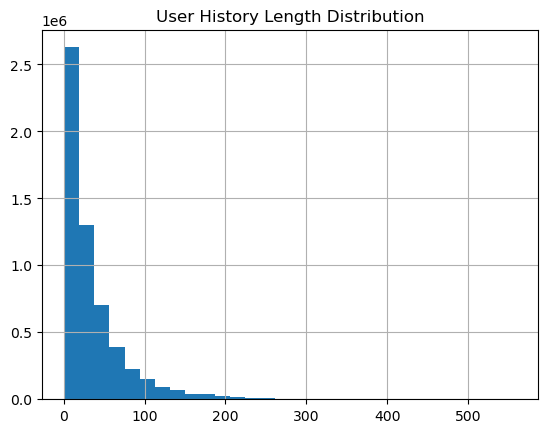

In [14]:
import ast

behaviors_clean["history_len"] = behaviors_clean["history"].apply(lambda x: len(ast.literal_eval(x)))
behaviors_clean["history_len"].hist(bins=30)
plt.title("User History Length Distribution")
plt.show()

In [15]:
print("Number of users:", behaviors_clean["user_id"].nunique())

Number of users: 49108


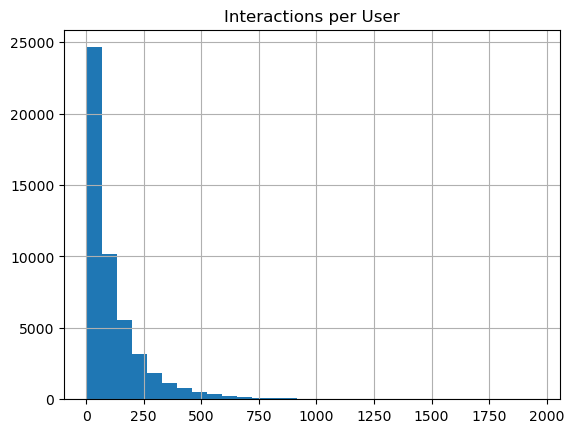

In [16]:
user_counts = behaviors_clean.groupby("user_id").size()
user_counts.hist(bins=30)
plt.title("Interactions per User")
plt.show()

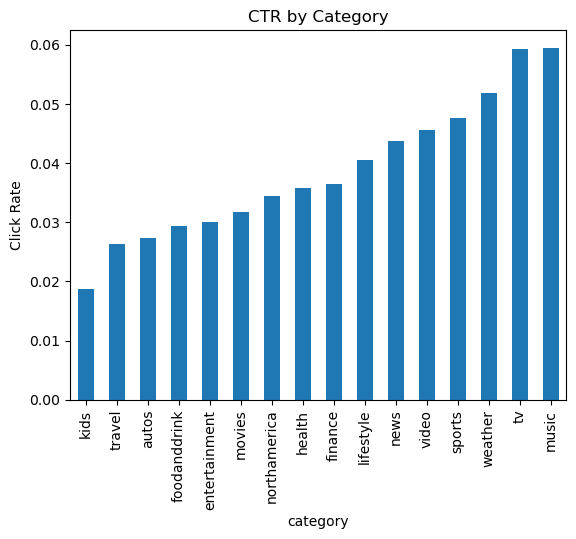

In [19]:
# Clicks per Category (click rate on impression)
behaviors_clean.groupby("category")["label"].mean().sort_values().plot(kind="bar")
plt.title("CTR by Category")
plt.ylabel("Click Rate")
plt.show()

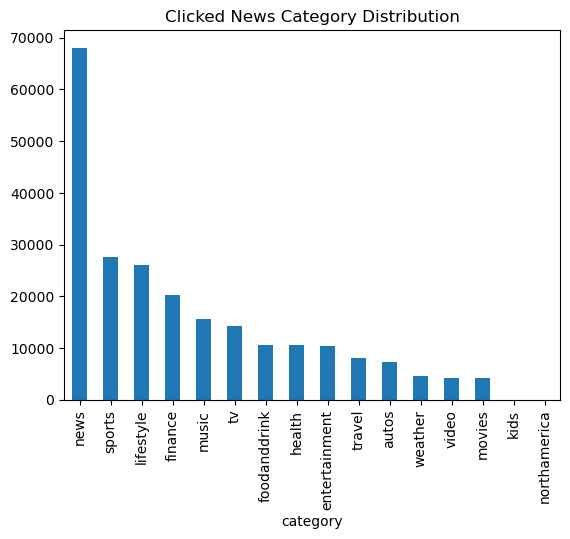

In [20]:
behaviors_clean[behaviors_clean["label"] == 1]["category"].value_counts().plot(kind="bar")
plt.title("Clicked News Category Distribution")
plt.show()

/var/folders/bq/hl2d1mzx4ln4s9vk722gsfv80000gn/T/ipykernel_14812/1302295950.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behaviors_clean.groupby("history_bin")["label"].mean().plot(kind="bar")


<Axes: xlabel='history_bin'>

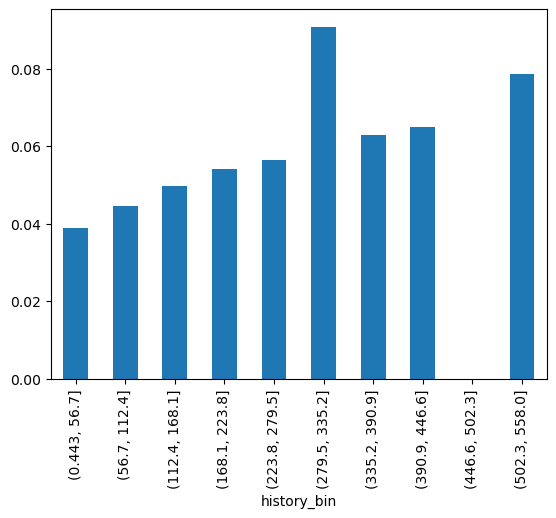

In [ ]:

behaviors_clean["history_bin"] = pd.cut(behaviors_clean["history_len"], bins=10)

behaviors_clean.groupby("history_bin")["label"].mean().plot(kind="bar")

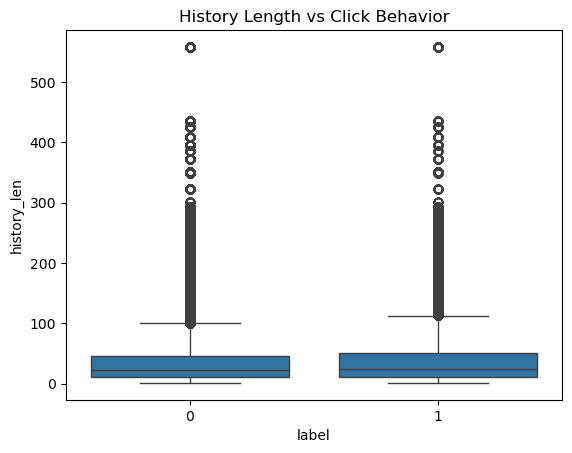